<a href="https://colab.research.google.com/github/DarshaPadmanban/24ADI003_24BAD017/blob/main/24BAD017_ML_EXP_9(SC_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip


--2026-04-08 13:57:48--  http://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-100k.zip [following]
--2026-04-08 13:57:48--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  6.82MB/s    in 0.7s    

2026-04-08 13:57:49 (6.82 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml


Item-User Matrix Shape: (1682, 943)

Item Similarity Matrix:
 movieId         1         2         3         4         5
movieId                                                  
1        1.000000  0.402382  0.330245  0.454938  0.286714
2        0.402382  1.000000  0.273069  0.502571  0.318836
3        0.330245  0.273069  1.000000  0.324866  0.212957
4        0.454938  0.502571  0.324866  1.000000  0.334239
5        0.286714  0.318836  0.212957  0.334239  1.000000

Recommended Movies (Item-Based):

     movieId                             title
55        56               Pulp Fiction (1994)
97        98  Silence of the Lambs, The (1991)
171      172   Empire Strikes Back, The (1980)
173      174    Raiders of the Lost Ark (1981)
203      204         Back to the Future (1985)

RMSE (Item-Based): 0.96
Precision@5: 1.0


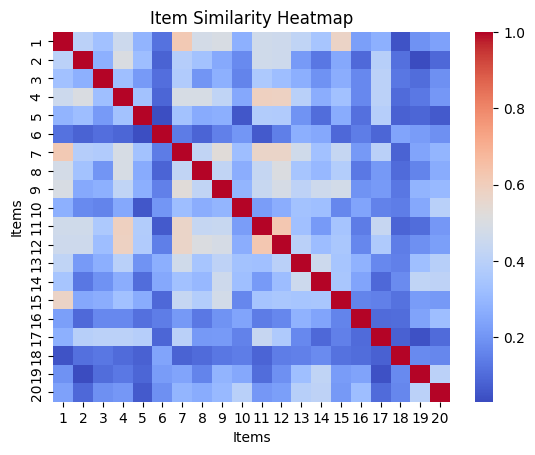

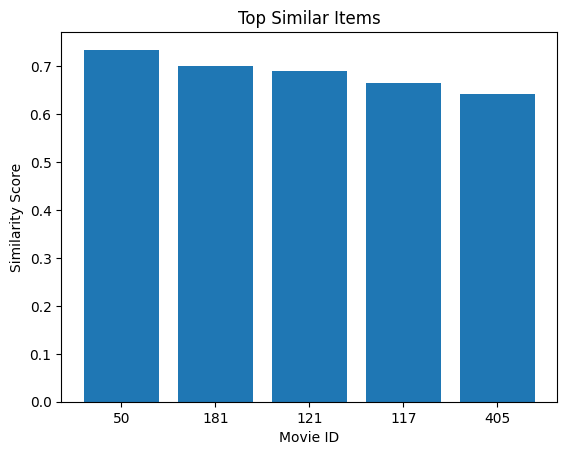

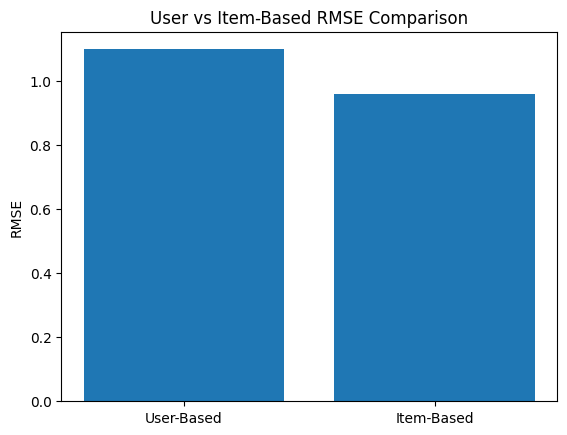

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

ratings = pd.read_csv(
    "/content/ml-100k/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

movies = pd.read_csv(
    "/content/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=["movieId", "title"] + [str(i) for i in range(22)]
)[["movieId", "title"]]
item_user = ratings.pivot(index='movieId', columns='userId', values='rating')
item_user_filled = item_user.fillna(0)
print("\nItem-User Matrix Shape:", item_user.shape)
item_similarity = cosine_similarity(item_user_filled)
item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_user.index,
                                  columns=item_user.index)
print("\nItem Similarity Matrix:\n", item_similarity_df.iloc[:5, :5])
def get_similar_items(movie_id, n=5):
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(movie_id)
    return sim_scores.head(n)
def recommend_items(user_id, n=5):
    user_ratings = ratings[ratings['userId'] == user_id]
    scores = {}
    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']

        similar_movies = get_similar_items(movie, n=10)

        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in scores:
                scores[sim_movie] = 0
            scores[sim_movie] += sim_score * rating
    sorted_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommended_ids = [i[0] for i in sorted_movies[:n]]
    return movies[movies['movieId'].isin(recommended_ids)][['movieId', 'title']]
user_id = 1
print("\nRecommended Movies (Item-Based):\n")
print(recommend_items(user_id, 5))
actual = []
predicted = []
for user in ratings['userId'].unique()[:50]:
    user_data = ratings[ratings['userId'] == user]
    for _, row in user_data.iterrows():
        movie = row['movieId']
        true_rating = row['rating']
        similar_items = get_similar_items(movie, n=10)
        pred = 0
        total_sim = 0
        for sim_movie, sim_score in similar_items.items():
            if not np.isnan(item_user.loc[sim_movie, user]):
                pred += sim_score * item_user.loc[sim_movie, user]
                total_sim += abs(sim_score)
        if total_sim != 0:
            pred /= total_sim
        else:
            pred = item_user.mean().mean()
        actual.append(true_rating)
        predicted.append(pred)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE (Item-Based):", round(rmse, 3))
def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, k)
    recommended_ids = recommended['movieId'].values
    actual_movies = ratings[(ratings['userId'] == user_id) & (ratings['rating'] >= 4)]['movieId'].values
    relevant = set(recommended_ids).intersection(set(actual_movies))
    return len(relevant) / k
precision = precision_at_k(user_id, 5)
print("Precision@5:", round(precision, 3))
plt.figure()
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.xlabel("Items")
plt.ylabel("Items")
plt.show()
movie_id = 1
similar_items = get_similar_items(movie_id, 5)

plt.figure()
plt.bar(similar_items.index.astype(str), similar_items.values)
plt.title("Top Similar Items")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()
user_rmse = 1.1
plt.figure()
models = ['User-Based', 'Item-Based']
values = [user_rmse, rmse]
plt.bar(models, values)
plt.title("User vs Item-Based RMSE Comparison")
plt.ylabel("RMSE")
plt.show()